# Plotting

We have multiple data files that we want to plot to visualize the data. Using the same scenario as before, lets plot the files using the data hierarchy.

## Generate Data

This time we generate 100 files.

In [1]:
import numpy as np
import pandas as pd
import os
import shutil


def generate_data(saveloc):
    """Generate example data for the project
    This generates 10 csv files with time and voltage columns. Each file is
    tagged with a metastring, the input voltage is labeled in the filename
    
    Parameters
    ----------
    saveLoc : string
        path to save the data.
    """
    # waveform parameters
    f = 1e3                       # frequency
    T = 1/f                       # Period
    t = np.linspace(0,10*T,1000)  # time vector, 10 periods
    gain = 2                      # gain of the circuit (Vout/Vin)
    
    
    # delete the contents of the folder if it exists
    if os.path.exists(saveloc):
        shutil.rmtree(saveloc)  # this command fails if directory doesnt exist
    # create the save directory if it doesn't exist
    if not os.path.exists(saveloc):
        os.makedirs(saveloc)    # this command fails if the directory exists already
        
    Vins = np.linspace(1,10,100)
    for Vin in Vins:
        Vnew = Vin*np.sqrt(2)*gain*np.sin(2*np.pi*f*t)       # output voltage
        
        # save waveform
        savename = 'waveform_Vin-%0.2f.csv'%Vin   # save name defining Vin by the dmanage naming convention
        data = np.stack([t,Vnew]).T   # combine t and V into one 2D array, first col is t and second is V
        waveform = pd.DataFrame(data,columns=['Time','Voltage'])   # create pandas dataframe
        waveform.to_csv(saveloc+savename,index=False)              # save to a file
    return 
saveloc = './test_data/'           # save location
generate_data(saveloc)             # generate data

## Plot Data

And now we setup our DataUnit and DataGroup like before, but with a plot_waveform() method; other methods are removed for simplicity. This method plots and saves the plot in a directory. We also add a DataFrame method plotting object and some save file location attributes to our DataUnit. 

In [2]:
from pathlib import Path
from dmanage.group import make_data_group
from dmanage.unit import make_data_unit
from dmanage.decorate import override
from dmanage.metadata.metastring import parse
import dmanage.dfmethods as dfm

DataUnit = make_data_unit()
class DataFile(DataUnit):
    def __init__(self,filepath):
        self.dataUnit = filepath
        self.baseDir = os.path.join(os.path.dirname(filepath),'')
        self.resultDir = self.baseDir + 'processed/'    # location twhere to save the plots.
        self.Plot = dfm.plot.Plot()             # This has DataFrame Methods for plotting
        
    def is_valid(self,dataFile):
        return ('.csv' in dataFile)
    
    def savetag(self):
        """extract the metastring from the filename
        """
        filename = Path(self.dataUnit).stem
        return filename.split('_')[-1]
        
    @override()
    def read_waveform(self):
        df = pd.read_csv(self.dataUnit)
        df = df.set_index('Time')
        return df
        
    @override()
    def plot_waveform(self,savename,saveloc=None,fig=1):
        """Plots and saves the waveform
        
        Parameters
        ----------
        savename : string
            This is the basename of the save string, the extension and a metastring 
            will be added.
        saveloc : string, optional
            the location to save the plots. If None is used, the save location will be 
            in self.resultDir. The default is None.
        """
        if saveloc is None:
           saveloc = self.resultDir
        if not os.path.exists(saveloc):
           os.makedirs(saveloc)
        savetag = self.savetag()
        df = self.read_waveform()
        fig,ax = self.Plot.plot1d(df)
        savename = savename + savetag + '.' + self.Plot.P.saveType
        fig.savefig(saveloc + savename, bbox_inches='tight', format=self.Plot.P.saveType)

DataDir = make_data_group(DataFile)
class DataDirectory(DataDir):
    """
    Data Directory class that reads all csv waveform files in a directory and gives access
    to wrapped DataFile class methods. Each method in the DataFile class is wrapped with the
    parrallelize_iterator_method to step through all detected waveform files

    The attribute self.dataUnits containes a list of all valid csv files
    """
    # This overrides the DataFile method and uses the DataDir self.dataUnits Parameter
    def parse_filename(self):
        return parse(self.dataUnits, 'Vin')  # We utilize the self.dataUnits attribute here instead

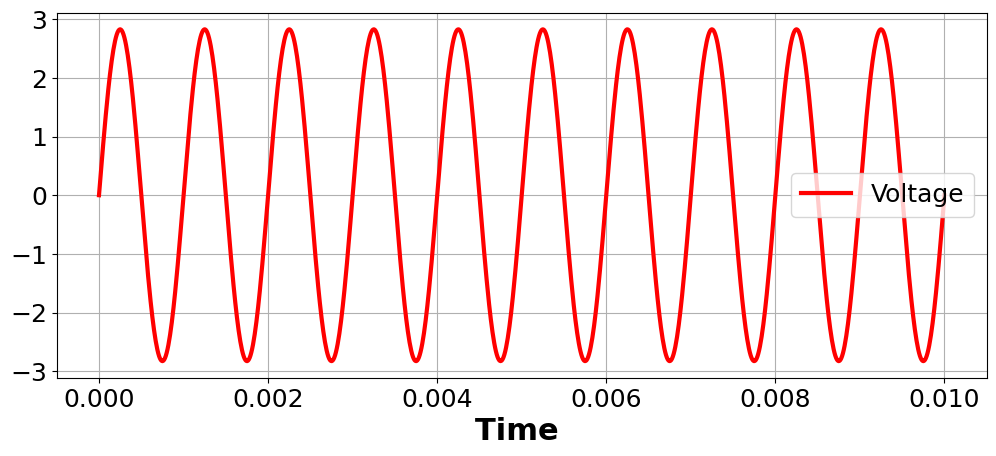

In [3]:
# plot one waveform to test
# file inputs
dataloc = saveloc           # save location
dataFile = 'waveform_Vin-1.00.csv'
generate_data(dataloc)             # generate data

D = DataFile(dataloc+dataFile)
D.plot_waveform('waveform')       

So the plot_waveform method creates a 'processed/' directory in the 'test_data/' directory, plots, and saves the plot there. The plot is named the same as the data file, but with a png extension. Now we can plot all of them using the DataDirectory class. Lets execute and time this process.

Opening ./test_data/... Done in 0.002 Seconds
Time to execute command: 10.76 seconds


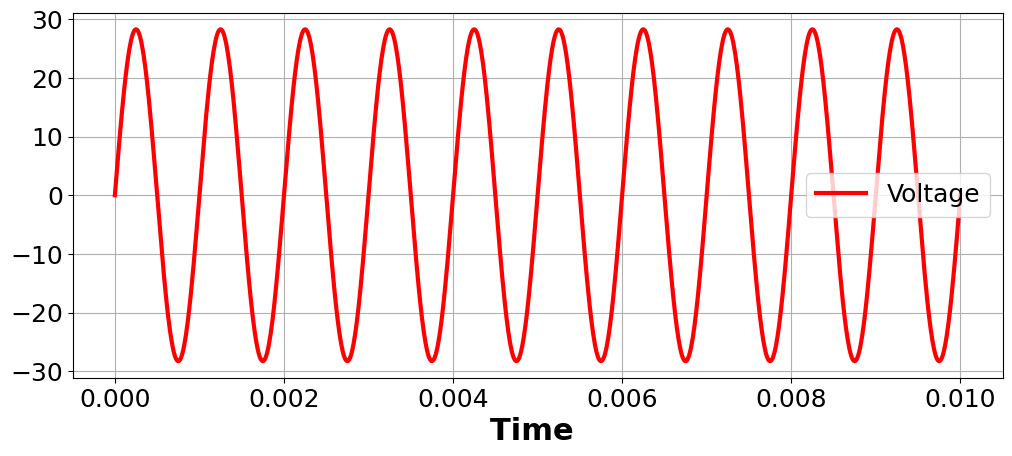

In [4]:
import time
DD = DataDirectory(dataloc,dataUnitType='files')
startTime = time.time()
DD.plot_waveform('waveform',nc=1);
executionTime = time.time() - startTime
print('Time to execute command: %0.2f seconds'%executionTime)


So this plotting process does take some time to read and plot 100 files. Lets try with multiple cores. The DataGroup wraps the DataUnit methods with a parallel implementation, all we need to do is use the `nc` parameter. 

In [5]:
startTime = time.time()
DD.plot_waveform('waveform',nc=4);
executionTime = time.time() - startTime
print('Time to execute command: %0.2f seconds'%executionTime)

Time to execute command: 3.61 seconds


So there is a significant speedup to using multiple cores to read and plot the data. That is if you are using an SSD! If you use a Hard Drive, this might be slower, because accessing the drive requires movement of a magnetic arm. The SSD just has to flip some bits to read, so it is faster.

**__NOTE:__** Sometimes plotting with multiple cores can add some artifacts to the plot or just outright crash. This, I think, is caused by the plotting backend and/or each process attempting to access the same figure to plot at the same time. This creates sporadic errors. To solve this issue, we can change the backend before plotting (and change it back in the after) and have each process plot in their own figure.


To Do, show this implementation???

Lets delete all that data

In [6]:
shutil.rmtree(dataloc)  # removes directory and contents. Be careful not to delete important stuff